In [10]:
# Cell 1: Setup & Imports
import os
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, cohen_kappa_score
from sklearn.model_selection import train_test_split

# Paths
DATA_PATH    = "/kaggle/input/datasets/lakshya4518/dataset-final/customer_support_tickets.csv"
OUTPUT_DIR   = "/kaggle/working/models/deberta_final"
PSEUDO_PATH  = "/kaggle/working/pseudo_labeled.csv"
DOSSIER_DIR  = "/kaggle/working/dossiers"
MODEL_NAME   = "microsoft/deberta-v3-small"

# Constants
PRIORITY_MAP = {"Low":1, "Medium":2, "High":3, "Critical":4}
NUM_TO_LABEL = {1:"Low", 2:"Medium", 3:"High", 4:"Critical"}
PRIORITY_ORDER = ["Low", "Medium", "High", "Critical"]

def to_num(x):
    return PRIORITY_MAP.get(str(x).strip(), 2)

print("Imports done")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Imports done
GPU: Tesla T4


In [13]:
# Cell 2: Data Loading
df = pd.read_csv(DATA_PATH)
print(f"Shape     : {df.shape}")

Shape     : (20000, 12)


In [14]:
df.head(5)

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [15]:
print(f"Columns   : {df.columns.tolist()}")

Columns   : ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']


In [16]:
print(f"\nDtypes:\n{df.dtypes}")


Dtypes:
Ticket_ID                object
Customer_Name            object
Customer_Email           object
Ticket_Subject           object
Ticket_Description       object
Issue_Category           object
Priority_Level           object
Ticket_Channel           object
Submission_Date          object
Resolution_Time_Hours     int64
Assigned_Agent           object
Satisfaction_Score        int64
dtype: object


In [17]:
print(f"\nMissing values:\n{df.isnull().sum()}")


Missing values:
Ticket_ID                0
Customer_Name            0
Customer_Email           0
Ticket_Subject           0
Ticket_Description       0
Issue_Category           0
Priority_Level           0
Ticket_Channel           0
Submission_Date          0
Resolution_Time_Hours    0
Assigned_Agent           0
Satisfaction_Score       0
dtype: int64


In [18]:
print(f"\nSample:\n{df.head(3).to_string()}")


Sample:
    Ticket_ID   Customer_Name              Customer_Email                   Ticket_Subject                                                                                  Ticket_Description   Issue_Category Priority_Level Ticket_Channel Submission_Date  Resolution_Time_Hours   Assigned_Agent  Satisfaction_Score
0  TKT-100000    George Simon  lisastrickland@example.com  Hours of operation - Individual                    Hi Support, Where is your headquarters located? Lay soon message show know main.  General Inquiry           High       Web Form      2025-07-02                     43        David Kim                   5
1  TKT-100001  Scott Thompson          wevans@example.org          Data not syncing - Card  Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.        Technical           High           Chat      2025-06-28                     41  Elena Rodriguez                   5
2  TKT-100002  Jennifer Smith        oleonard@exa

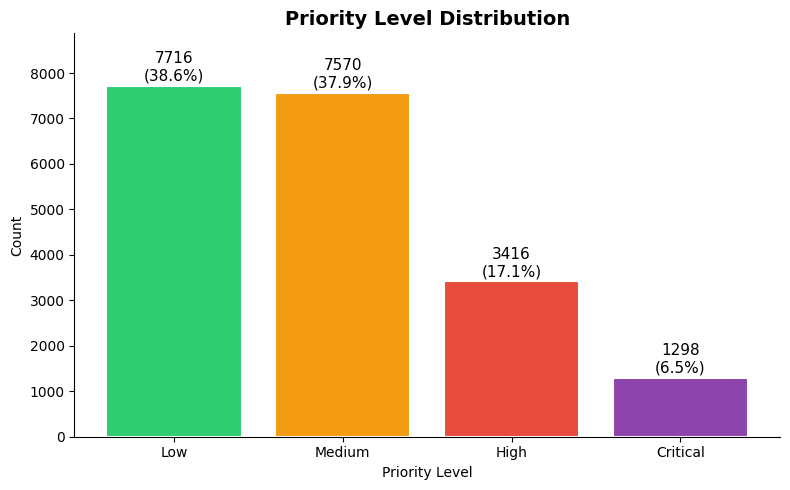

Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64


In [19]:
# Cell 3: EDA - Priority Level Distribution
fig, ax = plt.subplots(figsize=(8, 5))

priority_counts = df["Priority_Level"].value_counts()
colors = ["#2ecc71","#f39c12","#e74c3c","#8e44ad"]
bars = ax.bar(priority_counts.index, priority_counts.values, color=colors, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title("Priority Level Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Priority Level")
ax.set_ylabel("Count")
ax.set_ylim(0, priority_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig("/kaggle/working/eda_priority_dist.png", dpi=150)
plt.show()
print(priority_counts)

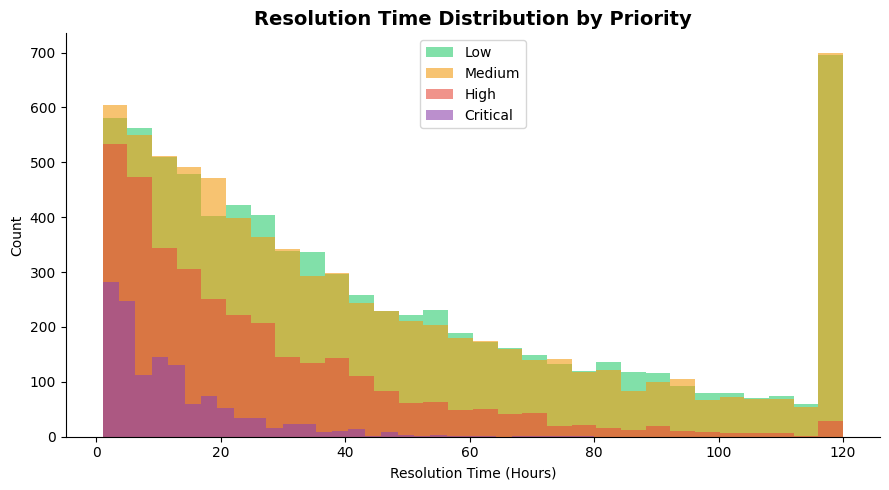

Resolution Time Stats by Priority:
                 count   mean    std  min   25%   50%   75%    max
Priority_Level                                                    
Critical        1298.0  12.07  11.38  1.0   4.0   9.0  16.0   80.0
High            3416.0  24.52  23.24  1.0   7.0  17.0  35.0  120.0
Low             7716.0  45.17  36.65  1.0  15.0  34.0  68.0  120.0
Medium          7570.0  44.47  36.81  1.0  14.0  33.0  67.0  120.0


In [20]:
# Cell 4: EDA - Resolution Time by Priority
fig, ax = plt.subplots(figsize=(9, 5))

for i, priority in enumerate(PRIORITY_ORDER):
    data = df[df["Priority_Level"] == priority]["Resolution_Time_Hours"].dropna()
    ax.hist(data, bins=30, alpha=0.6, label=priority, color=colors[i])

ax.set_title("Resolution Time Distribution by Priority", fontsize=14, fontweight="bold")
ax.set_xlabel("Resolution Time (Hours)")
ax.set_ylabel("Count")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("/kaggle/working/eda_resolution_time.png", dpi=150)
plt.show()

print("Resolution Time Stats by Priority:")
print(df.groupby("Priority_Level")["Resolution_Time_Hours"].describe().round(2))

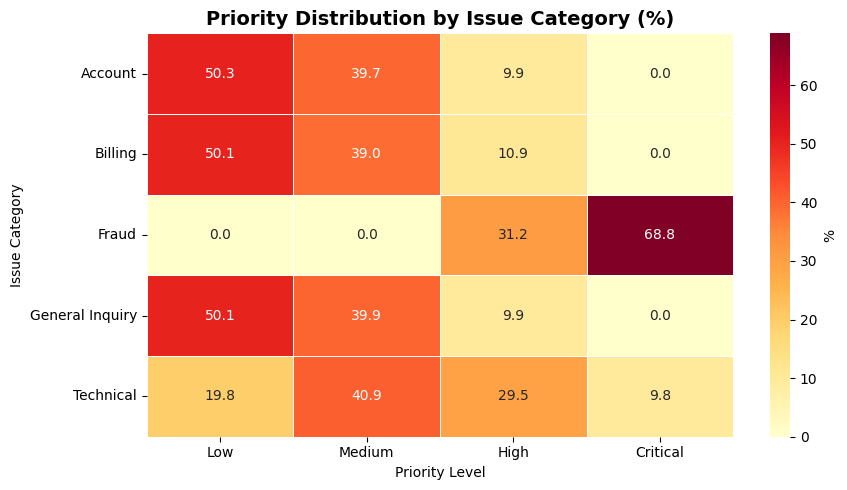

In [21]:
# Cell 5: EDA - Issue Category vs Priority Heatmap
pivot = pd.crosstab(
    df["Issue_Category"],
    df["Priority_Level"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot[PRIORITY_ORDER],
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "%"}
)
ax.set_title("Priority Distribution by Issue Category (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Priority Level")
ax.set_ylabel("Issue Category")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_category_priority.png", dpi=150)
plt.show()

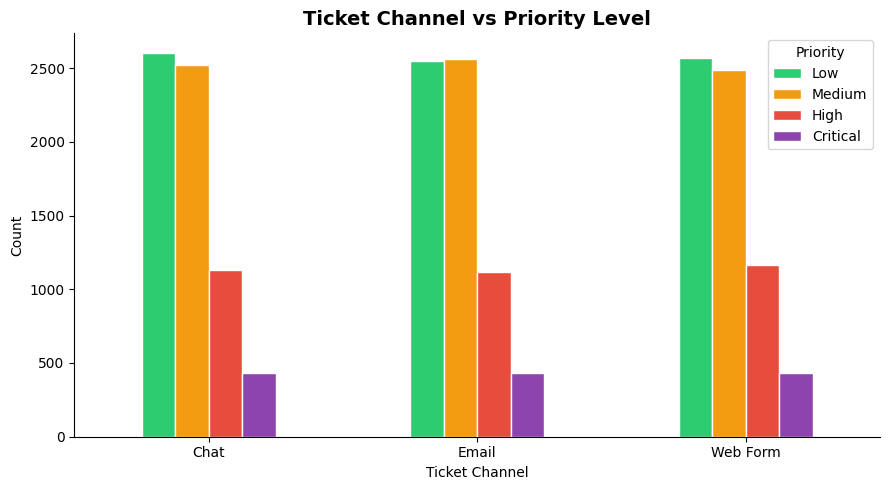

In [22]:
# Cell 6: EDA - Ticket Channel vs Priority
pivot_ch = pd.crosstab(
    df["Ticket_Channel"],
    df["Priority_Level"]
)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_ch[PRIORITY_ORDER].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Ticket Channel vs Priority Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Ticket Channel")
ax.set_ylabel("Count")
ax.legend(title="Priority")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig("/kaggle/working/eda_channel_priority.png", dpi=150)
plt.show()

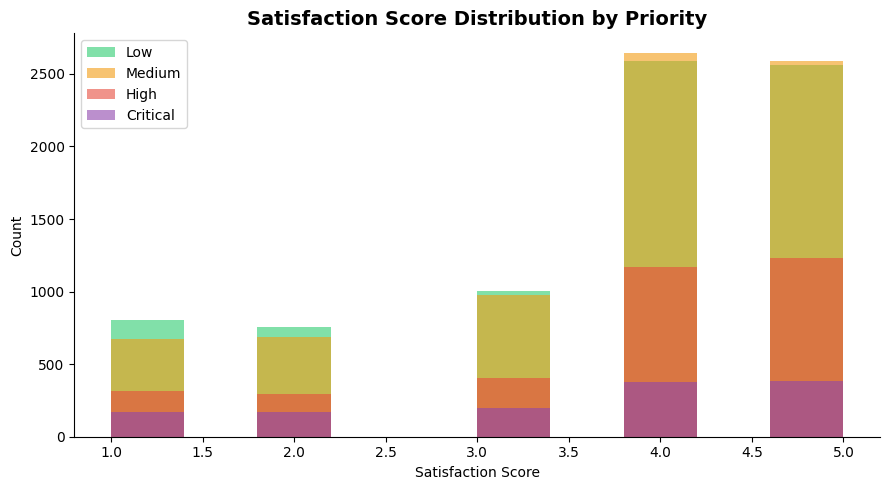

Avg Satisfaction by Priority:
Priority_Level
Critical    3.490
High        3.794
Low         3.692
Medium      3.764
Name: Satisfaction_Score, dtype: float64


In [23]:
# Cell 7: EDA - Satisfaction Score vs Priority
fig, ax = plt.subplots(figsize=(9, 5))

for i, priority in enumerate(PRIORITY_ORDER):
    data = df[df["Priority_Level"] == priority]["Satisfaction_Score"].dropna()
    ax.hist(data, bins=10, alpha=0.6, label=priority, color=colors[i])

ax.set_title("Satisfaction Score Distribution by Priority", fontsize=14, fontweight="bold")
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Count")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("/kaggle/working/eda_satisfaction.png", dpi=150)
plt.show()

print("Avg Satisfaction by Priority:")
print(df.groupby("Priority_Level")["Satisfaction_Score"].mean().round(3))

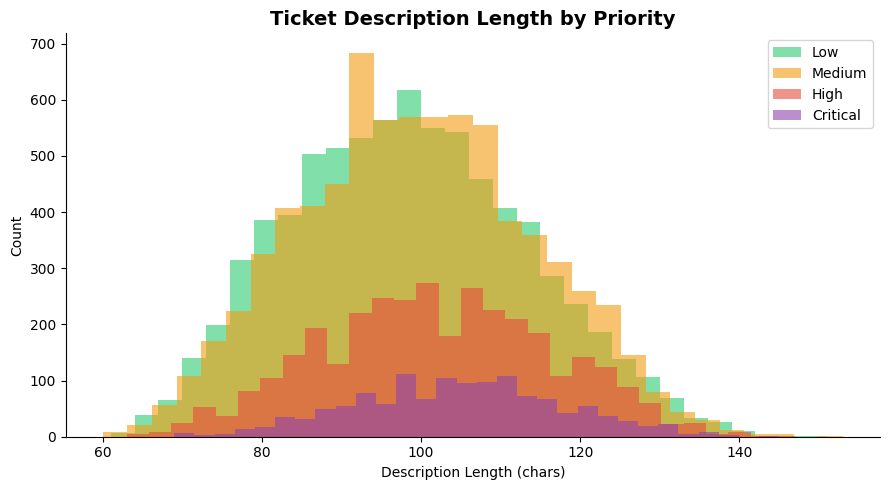

Avg Description Length by Priority:
Priority_Level
Critical    104.7
High        101.9
Low          97.9
Medium       99.4
Name: desc_len, dtype: float64


In [24]:
# Cell 8: EDA - Text Length Analysis
df["subject_len"] = df["Ticket_Subject"].fillna("").apply(len)
df["desc_len"]    = df["Ticket_Description"].fillna("").apply(len)

fig, ax = plt.subplots(figsize=(9, 5))

for i, priority in enumerate(PRIORITY_ORDER):
    data = df[df["Priority_Level"] == priority]["desc_len"]
    ax.hist(data, bins=30, alpha=0.6, label=priority, color=colors[i])

ax.set_title("Ticket Description Length by Priority", fontsize=14, fontweight="bold")
ax.set_xlabel("Description Length (chars)")
ax.set_ylabel("Count")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("/kaggle/working/eda_text_length.png", dpi=150)
plt.show()

print("Avg Description Length by Priority:")
print(df.groupby("Priority_Level")["desc_len"].mean().round(1))

In [25]:
# Cell 9: Feature Engineering
CRITICAL_PHRASES = [
    "system down","outage","data loss","security breach","data breach",
    "production down","cannot access","complete failure","total failure",
    "breach","hacked","stolen","phishing","fraud","unauthorized",
    "account compromised","ransomware"
]
HIGH_PHRASES = [
    "urgent","broken","failed","crash","not working","corrupted",
    "missing data","blocked","locked out","payment failed",
    "charged twice","login failed","cannot login","2fa issues",
    "screen freezes","data not syncing"
]
LOW_PHRASES = [
    "how to","question","wondering","inquiry","feature request",
    "suggestion","typo","color","font","alignment","cosmetic",
    "hours of operation","office location","faq","where is","password reset"
]

def extract_features(df):
    df = df.copy()
    texts = (df["Ticket_Subject"].fillna("") + " " +
             df["Ticket_Description"].fillna("")).str.lower()

    # Keyword features
    df["has_critical_phrase"] = texts.apply(
        lambda t: int(any(p in t for p in CRITICAL_PHRASES))
    )
    df["has_high_phrase"] = texts.apply(
        lambda t: int(any(p in t for p in HIGH_PHRASES))
    )
    df["has_low_phrase"] = texts.apply(
        lambda t: int(any(p in t for p in LOW_PHRASES))
    )
    df["has_negation"] = texts.apply(
        lambda t: int(any(n in t.split() for n in ["not","doesn't","don't","can't","never"]))
    )

    # Text stats
    df["desc_word_count"]   = df["Ticket_Description"].fillna("").apply(lambda x: len(x.split()))
    df["subject_word_count"]= df["Ticket_Subject"].fillna("").apply(lambda x: len(x.split()))
    df["exclamation_count"] = df["Ticket_Description"].fillna("").apply(lambda x: x.count("!"))
    df["caps_ratio"]        = df["Ticket_Description"].fillna("").apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )

    # Resolution time features
    median_res = df["Resolution_Time_Hours"].median()
    df["res_time_filled"]   = df["Resolution_Time_Hours"].fillna(median_res)
    df["res_above_median"]  = (df["res_time_filled"] > median_res).astype(int)
    df["res_above_75pct"]   = (df["res_time_filled"] > df["res_time_filled"].quantile(0.75)).astype(int)

    # Satisfaction features
    df["sat_filled"]     = df["Satisfaction_Score"].fillna(3)
    df["low_satisfaction"]= (df["sat_filled"] <= 2).astype(int)

    return df

df = extract_features(df)
print("✓ Feature engineering done")
print(f"New features added: {['has_critical_phrase','has_high_phrase','has_low_phrase','has_negation','desc_word_count','exclamation_count','caps_ratio','res_above_median','low_satisfaction']}")
print(f"\nCritical phrase tickets: {df['has_critical_phrase'].sum()}")
print(f"High phrase tickets   : {df['has_high_phrase'].sum()}")
print(f"Low phrase tickets    : {df['has_low_phrase'].sum()}")

✓ Feature engineering done
New features added: ['has_critical_phrase', 'has_high_phrase', 'has_low_phrase', 'has_negation', 'desc_word_count', 'exclamation_count', 'caps_ratio', 'res_above_median', 'low_satisfaction']

Critical phrase tickets: 543
High phrase tickets   : 6586
Low phrase tickets    : 5209


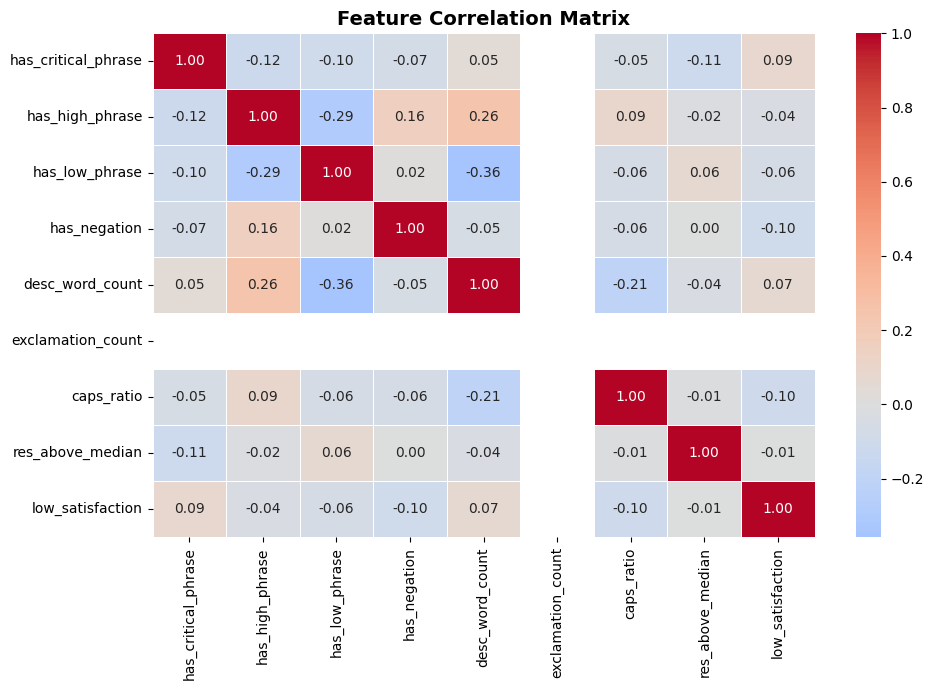

In [26]:
# Cell 10: Feature Correlation Heatmap
feature_cols = [
    "has_critical_phrase","has_high_phrase","has_low_phrase",
    "has_negation","desc_word_count","exclamation_count",
    "caps_ratio","res_above_median","low_satisfaction"
]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_feature_corr.png", dpi=150)
plt.show()

In [27]:
# Cell 11: Pseudo Label Generation (Stage 1)
def generate_pseudo_labels(df):
    print("[Stage 1] Generating pseudo labels...")

    times       = df["Resolution_Time_Hours"].fillna(df["Resolution_Time_Hours"].median())
    q25, q50, q75 = times.quantile([0.25, 0.50, 0.75])
    time_median = times.median()

    mismatch_labels, mismatch_types  = [], []
    severity_deltas, inferred_labels = [], []
    rule_scores_list, res_scores_list = [], []

    for _, row in df.iterrows():
        text     = str(row["Ticket_Subject"]) + " " + str(row["Ticket_Description"])
        t        = text.lower()
        assigned = to_num(row["Priority_Level"])

        # Rule score
        rule_score = assigned
        if any(p in t for p in CRITICAL_PHRASES): rule_score = 4
        elif any(p in t for p in HIGH_PHRASES):   rule_score = 3
        elif any(p in t for p in LOW_PHRASES):    rule_score = 1
        if any(n in t.split() for n in ["not","doesn't","don't","can't","never"]):
            rule_score = max(1, rule_score - 1)

        # Resolution score
        rh = row["Resolution_Time_Hours"] if pd.notna(row["Resolution_Time_Hours"]) else time_median
        if rh <= q25:   res_score = 1
        elif rh <= q50: res_score = 2
        elif rh <= q75: res_score = 3
        else:           res_score = 4

        rule_scores_list.append(rule_score)
        res_scores_list.append(res_score)

        rule_gap  = rule_score - assigned
        res_gap   = res_score  - assigned
        same_dir  = rule_gap * res_gap > 0
        rule_strong = abs(rule_gap) >= 2
        res_strong  = abs(res_gap)  >= 2
        both_agree  = abs(rule_gap) >= 1 and abs(res_gap) >= 1 and same_dir

        is_mismatch = rule_strong or (res_strong and abs(rule_gap)>=1 and same_dir) or both_agree

        if is_mismatch:
            fused = max(1, min(4, round(0.6*rule_score + 0.4*res_score)))
            delta = fused - assigned
            mismatch_labels.append(1)
            mismatch_types.append("Hidden Crisis" if delta > 0 else "False Alarm")
            severity_deltas.append(delta)
            inferred_labels.append(NUM_TO_LABEL[fused])
        else:
            mismatch_labels.append(0)
            mismatch_types.append("Correct")
            severity_deltas.append(0)
            inferred_labels.append(NUM_TO_LABEL[assigned])

    df_out = df.copy()
    df_out["inferred_severity"] = inferred_labels
    df_out["severity_delta"]    = severity_deltas
    df_out["mismatch_label"]    = mismatch_labels
    df_out["mismatch_type"]     = mismatch_types
    df_out["rule_label"]        = [NUM_TO_LABEL[r] for r in rule_scores_list]
    df_out["res_label"]         = [NUM_TO_LABEL[r] for r in res_scores_list]
    df_out["emb_label"]         = [NUM_TO_LABEL[r] for r in rule_scores_list]

    n, total = sum(mismatch_labels), len(mismatch_labels)
    print(f"✓ Mismatch: {n} ({n/total:.1%}) | Correct: {total-n} ({(total-n)/total:.1%})")
    print(f"Types:\n{pd.Series(mismatch_types).value_counts()}")

    # Cohen's Kappa
    kappa = cohen_kappa_score(
        [to_num(x) for x in df_out["rule_label"]],
        [to_num(x) for x in df_out["res_label"]]
    )
    print(f"\nCohen's κ (Rule vs Resolution): {kappa:.4f}")

    return df_out

pseudo_df = generate_pseudo_labels(df)
pseudo_df.to_csv(PSEUDO_PATH, index=False)
print(f"✓ Saved → {PSEUDO_PATH}")

[Stage 1] Generating pseudo labels...
✓ Mismatch: 4919 (24.6%) | Correct: 15081 (75.4%)
Types:
Correct          15081
Hidden Crisis     3065
False Alarm       1854
Name: count, dtype: int64

Cohen's κ (Rule vs Resolution): -0.0447
✓ Saved → /kaggle/working/pseudo_labeled.csv


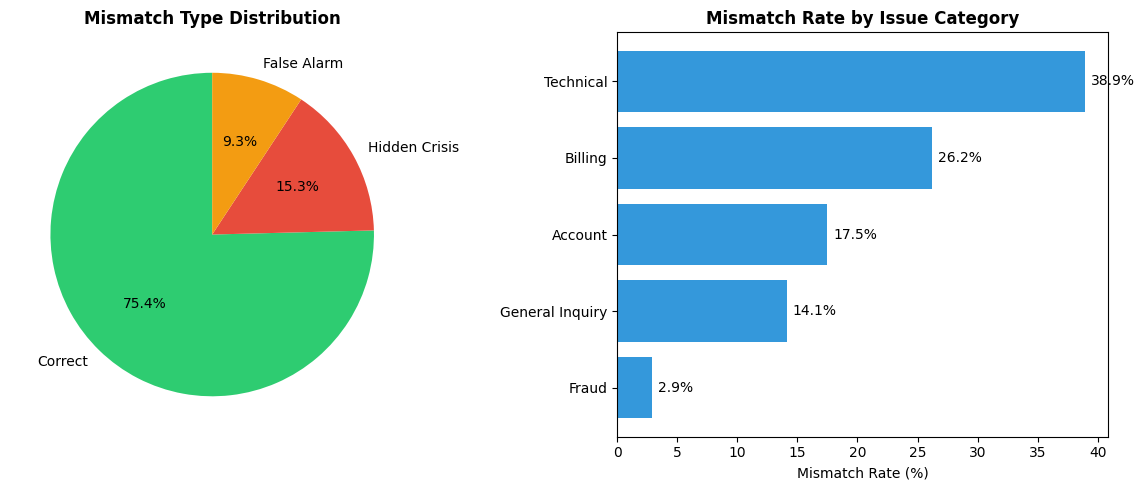

In [28]:
# Cell 12: EDA - Mismatch Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    pseudo_df["mismatch_type"].value_counts(),
    labels=pseudo_df["mismatch_type"].value_counts().index,
    autopct="%1.1f%%",
    colors=["#2ecc71","#e74c3c","#f39c12"],
    startangle=90
)
axes[0].set_title("Mismatch Type Distribution", fontweight="bold")

# Mismatch rate by category
cat_rate = pseudo_df.groupby("Issue_Category")["mismatch_label"].mean().sort_values()
axes[1].barh(cat_rate.index, cat_rate.values * 100,
             color=["#3498db"]*len(cat_rate))
axes[1].set_title("Mismatch Rate by Issue Category", fontweight="bold")
axes[1].set_xlabel("Mismatch Rate (%)")
for i, v in enumerate(cat_rate.values):
    axes[1].text(v*100 + 0.5, i, f"{v*100:.1f}%", va="center")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_mismatch_dist.png", dpi=150)
plt.show()

In [29]:
# Cell 13: Ablation Study
print("="*60)
print("ABLATION STUDY — Signal Contributions")
print("="*60)

assigned = pseudo_df["Priority_Level"].apply(to_num).tolist()
rule_scores = pseudo_df["rule_label"].apply(to_num).tolist()
res_scores  = pseudo_df["res_label"].apply(to_num).tolist()

combos = {
    "Rule Only":              rule_scores,
    "Resolution Only":        res_scores,
    "Rule+Res (0.6/0.4)":    [max(1,min(4,round(0.6*r+0.4*s))) for r,s in zip(rule_scores,res_scores)],
    "Rule+Res (0.5/0.5)":    [max(1,min(4,round(0.5*r+0.5*s))) for r,s in zip(rule_scores,res_scores)],
}

print(f"\n{'Signal Combination':<25} {'Mismatch%':>10} {'κ vs Primary':>12}")
print("-"*50)
primary = pseudo_df["mismatch_label"].tolist()
for name, scores in combos.items():
    preds = [1 if abs(s-a)>=1 else 0 for s,a in zip(scores, assigned)]
    pct   = sum(preds)/len(preds)
    try:    kappa = cohen_kappa_score(preds, primary)
    except: kappa = 0.0
    print(f"{name:<25} {pct:>10.1%} {kappa:>12.4f}")

ABLATION STUDY — Signal Contributions

Signal Combination         Mismatch% κ vs Primary
--------------------------------------------------
Rule Only                      40.1%       0.6559
Resolution Only                79.5%       0.0889
Rule+Res (0.6/0.4)             59.9%       0.3579
Rule+Res (0.5/0.5)             65.9%       0.2890


In [31]:
# Cell 14: Stage 2 — DeBERTa Training
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.labels = df["mismatch_label"].values

        res_bins = pd.qcut(
            df["Resolution_Time_Hours"].fillna(0), q=4,
            labels=["res_low","res_medium","res_high","res_critical"],
            duplicates="drop"
        ).astype(str)

        sat_bin = pd.cut(
            df["Satisfaction_Score"].fillna(3),
            bins=[0,2,3,4,5],
            labels=["very_dissatisfied","dissatisfied","neutral","satisfied"]
        ).astype(str)

        texts = (
            df["Ticket_Subject"].fillna("")     + " [SEP] " +
            df["Ticket_Description"].fillna("") + " [SEP] " +
            df["Ticket_Channel"].fillna("")     + " [SEP] " +
            df["Issue_Category"].fillna("")     + " [SEP] " +
            res_bins                            + " [SEP] " +
            sat_bin
        ).tolist()

        self.encodings = tokenizer(
            texts, truncation=True, padding=True,
            max_length=max_length, return_tensors="pt"
        )

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_df, temp_df = train_test_split(
    pseudo_df, test_size=0.2,
    stratify=pseudo_df["mismatch_label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df["mismatch_label"], random_state=42
)
print(f"Train:{len(train_df)} | Val:{len(val_df)} | Test:{len(test_df)}")

tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_ds     = TicketDataset(train_df, tokenizer)
val_ds       = TicketDataset(val_df,   tokenizer)
test_ds      = TicketDataset(test_df,  tokenizer)

counts       = np.bincount(train_df["mismatch_label"].values)
weights      = 1.0 / counts[train_df["mismatch_label"].values]
sampler      = WeightedRandomSampler(weights, len(weights))
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.float().to(device)

counts = np.bincount(train_df["mismatch_label"].values)
class_weights = torch.tensor(
    [1.0, counts[0]/counts[1] * 0.9], dtype=torch.float32
).to(device)
print(f"Class weights: {class_weights}")

criterion    = nn.CrossEntropyLoss(weight=class_weights)
optimizer    = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
total_steps  = len(train_loader) * 10
warmup_steps = total_steps // 10

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return max(0.1, 0.5 * (1 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_f1, best_threshold, patience = 0.0, 0.5, 0
os.makedirs(OUTPUT_DIR, exist_ok=True)
history = {"train_loss":[], "val_f1":[], "val_acc":[]}

for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)
        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits.float(), labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    model.eval()
    vprobs, vl = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            probs = torch.softmax(out.logits.float(), dim=-1)
            vprobs.extend(probs[:,1].cpu().numpy())
            vl.extend(batch["labels"].numpy())

    best_val_f1, best_thresh = 0.0, 0.5
    for thresh in np.arange(0.30, 0.85, 0.05):
        preds_t = (np.array(vprobs) >= thresh).astype(int)
        f1_t    = f1_score(vl, preds_t, average="macro", zero_division=0)
        if f1_t > best_val_f1:
            best_val_f1 = f1_t
            best_thresh = thresh

    val_acc = accuracy_score(vl, (np.array(vprobs) >= best_thresh).astype(int))
    avg_loss = total_loss/len(train_loader)
    history["train_loss"].append(avg_loss)
    history["val_f1"].append(best_val_f1)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/10 | Loss:{avg_loss:.4f} | Val F1:{best_val_f1:.4f} | Acc:{val_acc:.4f} | Thresh:{best_thresh:.2f}")

    if best_val_f1 > best_f1:
        best_f1 = best_val_f1
        best_threshold = best_thresh
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print(f"  ✓ Best saved (F1:{best_f1:.4f})")
        patience = 0
    else:
        patience += 1
        if patience >= 4:
            print("Early stopping!")
            break

print(f"\n✓ Training done! Best F1: {best_f1:.4f} at threshold {best_threshold:.2f}")

Train:16000 | Val:2000 | Test:2000
Device: cuda


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight       

Class weights: tensor([1.0000, 2.7595], device='cuda:0')
Epoch 1/10 | Loss:0.4488 | Val F1:0.7769 | Acc:0.8085 | Thresh:0.80


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✓ Best saved (F1:0.7941)
Epoch 6/10 | Loss:0.2524 | Val F1:0.7914 | Acc:0.8205 | Thresh:0.80
Epoch 7/10 | Loss:0.2471 | Val F1:0.7938 | Acc:0.8250 | Thresh:0.80
Epoch 8/10 | Loss:0.2320 | Val F1:0.8003 | Acc:0.8325 | Thresh:0.80


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best saved (F1:0.8003)
Epoch 9/10 | Loss:0.2349 | Val F1:0.8079 | Acc:0.8395 | Thresh:0.80


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best saved (F1:0.8079)
Epoch 10/10 | Loss:0.2307 | Val F1:0.8007 | Acc:0.8335 | Thresh:0.80

✓ Training done! Best F1: 0.8079 at threshold 0.80


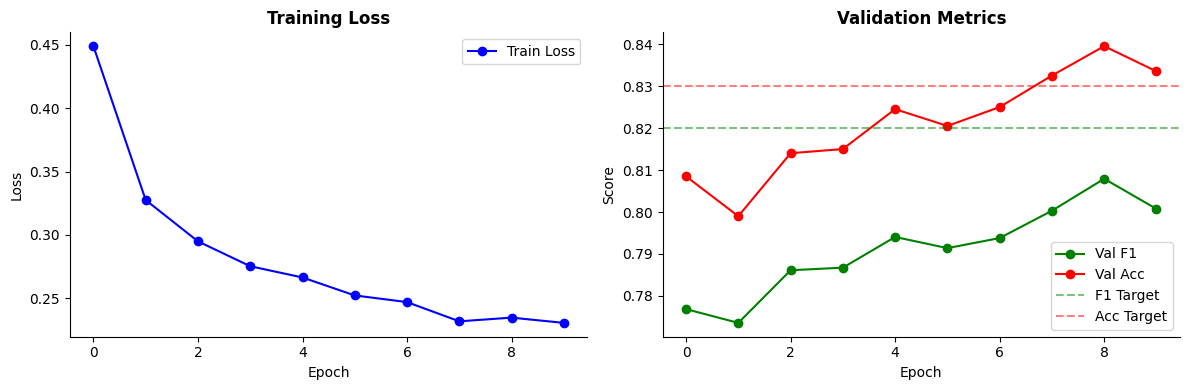

In [32]:
# Cell 15: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], "b-o", label="Train Loss")
axes[0].set_title("Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
sns.despine()

axes[1].plot(history["val_f1"],  "g-o", label="Val F1")
axes[1].plot(history["val_acc"], "r-o", label="Val Acc")
axes[1].axhline(y=0.82, color="g", linestyle="--", alpha=0.5, label="F1 Target")
axes[1].axhline(y=0.83, color="r", linestyle="--", alpha=0.5, label="Acc Target")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
sns.despine()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [33]:
# Cell 16: Final Evaluation
model.eval()
tprobs, tl = [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        out  = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits.float(), dim=-1)
        tprobs.extend(probs[:,1].cpu().numpy())
        tl.extend(batch["labels"].numpy())

tprobs = np.array(tprobs)
tl     = np.array(tl)
tp     = (tprobs >= best_threshold).astype(int)

acc    = accuracy_score(tl, tp)
f1     = f1_score(tl, tp, average="macro")
recall = recall_score(tl, tp, average=None)

print("="*55)
print("FINAL TEST RESULTS")
print("="*55)
print(f"Accuracy : {acc:.4f}  ({'✓' if acc>=0.83 else '✗'} Target≥0.83)")
print(f"Macro F1 : {f1:.4f}  ({'✓' if f1>=0.82 else '✗'} Target≥0.82)")
print(f"Recall[0]: {recall[0]:.4f}  ({'✓' if recall[0]>=0.78 else '✗'} Target≥0.78)")
print(f"Recall[1]: {recall[1]:.4f}  ({'✓' if recall[1]>=0.78 else '✗'} Target≥0.78)")
print(classification_report(tl, tp, target_names=["Correct","Mismatch"]))

FINAL TEST RESULTS
Accuracy : 0.8450  (✓ Target≥0.83)
Macro F1 : 0.8131  (✗ Target≥0.82)
Recall[0]: 0.8342  (✓ Target≥0.78)
Recall[1]: 0.8780  (✓ Target≥0.78)
              precision    recall  f1-score   support

     Correct       0.95      0.83      0.89      1508
    Mismatch       0.63      0.88      0.74       492

    accuracy                           0.84      2000
   macro avg       0.79      0.86      0.81      2000
weighted avg       0.88      0.84      0.85      2000



In [1]:
import os

# Folders banao
os.makedirs("/kaggle/working/sia", exist_ok=True)
os.makedirs("/kaggle/working/sia/data", exist_ok=True)
os.makedirs("/kaggle/working/sia/models", exist_ok=True)
os.makedirs("/kaggle/working/sia/outputs/dossiers", exist_ok=True)
os.makedirs("/kaggle/working/sia/src", exist_ok=True)
os.makedirs("/kaggle/working/sia/app", exist_ok=True)

print("✓ Folders created")

✓ Folders created
